# <center> Redes neuronales para el Procesamiento del Lenguaje Natural </center>  


# Práctica 4: Modelos Contextuales para Procesamiento del Lenguaje Natural
## Jesús Ferrándiz Alarcón

En esta práctica vamos a abordar un problema de Análisis de Sentimientos mediante el uso de Modelos Contextuales.

<!--
 Copyright 2025 Keybotic SL
  All Rights Reserved 
  
  Unauthorized copying of this file, via any medium is strictly prohibited, 
  unless it was supplied under the terms of a license agreement or 
  nondisclosure agreement with Keybotic SL. In this case it may not be 
  copied or disclosed except in accordance with the terms of that agreement.
-->



# Imports

Comenzamos importando una serie de módulos que usaremos después.

In [1]:
# Librerias necesarias
# Matplotlib conf
import matplotlib.pyplot as plt
%matplotlib inline
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':40,
         'ytick.labelsize': 40
}
plt.rcParams.update(params)
# Seaborn conf
import seaborn as sns
sns.set(style='darkgrid')
sns.set_palette(sns.color_palette("Blues"))

import sys

#Procesado de datos
import pandas as pd
import numpy as np
import operator

#Modelos
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Carga del Dataset, introspección y procesado
Cargamos el dataset como en las prácticas anteriores. Los datos tabulares en .csv se
leen y cargan en una estructura de pandas.

## Carga del dataset y pre procesado

In [2]:
training_set = pd.read_csv('./Dataset_reviews/train_reviews.csv')
print(f"Training set shape: {training_set.shape},* columns: {training_set.columns.tolist()}")
test_set = pd.read_csv('./Dataset_reviews/test_reviews.csv')
print(f"Test set shape: {test_set.shape}, columns: {test_set.columns.tolist()}")

Training set shape: (8000, 3),* columns: ['id', 'review', 'sentiment']
Test set shape: (2000, 3), columns: ['id', 'review', 'sentiment']


In [3]:
# Inspeccionamos el aspecto del conjunto de entrenamiento
training_set.head(20)

,id,review,sentiment
0,17527,People tried to make me believe that the premi...,negative
1,24155,I have been wanting to see cut since the day i...,positive
2,21972,This movie is terrible. The suspense is spent ...,negative
3,4565,I hope she can keep acting and directing. She'...,positive
4,22098,I fell in love with this silent action drama. ...,positive
5,5138,Shame Shame Shame on UA/DW for what you do! <b...,negative
6,16932,It's not very often a movie can literally make...,positive
7,13181,I was very interested to see this movie when i...,positive
8,3299,It might not be the best movie of 2006 but it ...,positive
9,18982,I went to see the Omega Code with a group of o...,negative


Revisamos el balance de clases.

([0, 1], [Text(0, 0, 'positive'), Text(1, 0, 'negative')])

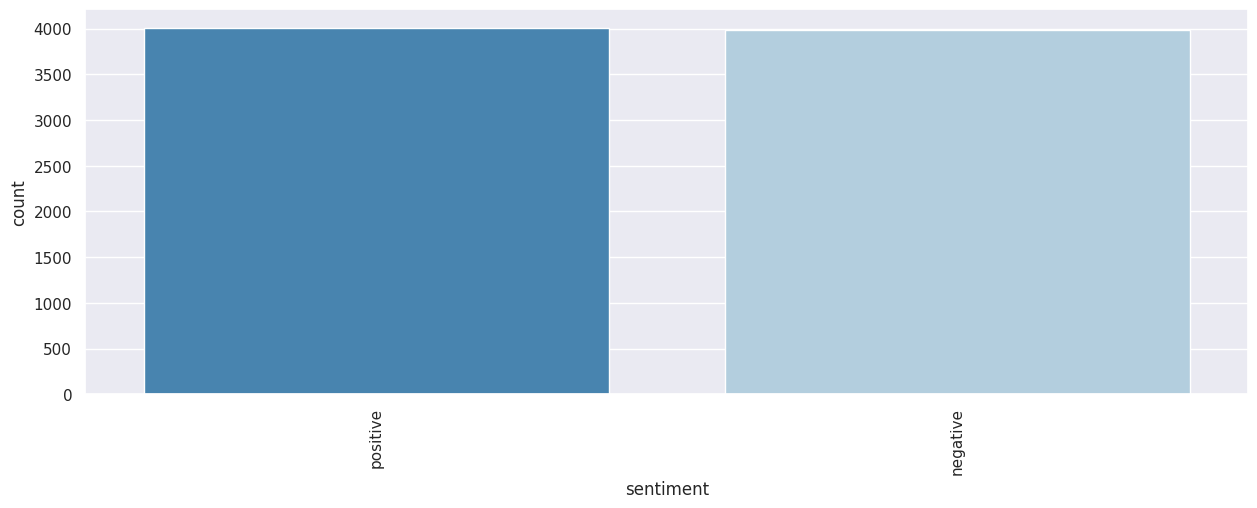

In [4]:
from collections import Counter
sns.countplot(data=training_set, x=training_set.sentiment, order=[x for x, count in sorted(Counter(training_set.sentiment).items(), key=lambda x: -x[1])], palette="Blues_r")
plt.xticks(rotation=90)

Hay un equilibrio entre el número de muestras de reseñas positivas y negativas.

A continuación vamos a procesar las reseñas. A diferencia con las prácticas anteriores, en este procesado, solo vamos a aplicar la eliminación de artefactos HTML. Esto se debe a que los modelos basados en transformers y hugging face que utilizaremos posteriormente implementarán sus propias técnicas de pre procesado, aquellas con la que el modelo ha sido entrenado.

Procesamos las reseñas solamente con:
- Eliminación de artefactos HTML


In [5]:
import sys
!{sys.executable} -m pip install beautifulsoup4

In [6]:
from bs4 import BeautifulSoup
import re

def strip_html_remove_links(text):
    soup = BeautifulSoup(text, "html.parser")
    for a in soup.find_all("a"):
        a.decompose()

    text = soup.get_text(separator=" ")

    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [7]:
def process_text(raw_text):
    text = strip_html_remove_links(raw_text)
    return text

In [8]:
dataset = pd.concat([training_set, test_set])
dataset.shape
dataset.columns

Index(['id', 'review', 'sentiment'], dtype='str')

In [9]:
import sys
!{sys.executable} -m pip install --upgrade tqdm

In [10]:
from tqdm import tqdm
tqdm.pandas()

dataset['processed_review'] = dataset['review'].progress_apply(lambda x: process_text(x))

100%|██████████| 10000/10000 [00:01<00:00, 7996.85it/s]


In [11]:
X_train = dataset[0:len(training_set)][["id", "processed_review"]]
y_train = dataset[0:len(training_set)][["sentiment"]]

X_test = dataset[len(training_set):len(dataset)][["id", "processed_review"]]
y_test = dataset[len(training_set):len(dataset)][["sentiment"]]

Codificamos las etiquetas del string 'positive', 'negative' a un
vector plano de 0's y 1's.
Donde 0 -> negative, 1 -> positive

In [12]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
print(f"Values before encoding: {y_train.sentiment.values}")
le.fit(y_train.sentiment.values)
target_labels = le.classes_
encoded_y_train = le.transform(y_train.sentiment.values)
print(f"Labels after encoding: {encoded_y_train}")

print(f"Target labels: {target_labels}")

encoded_y_test = le.transform(y_test.sentiment.values)


Values before encoding: <ArrowStringArray>
['negative', 'positive', 'negative', 'positive', 'positive', 'negative',
 'positive', 'positive', 'positive', 'negative',
 ...
 'negative', 'positive', 'positive', 'negative', 'positive', 'negative',
 'positive', 'negative', 'negative', 'negative']
Length: 8000, dtype: str
Labels after encoding: [0 1 0 ... 0 0 0]
Target labels: ['negative' 'positive']


In [13]:
Y_train = encoded_y_train  # Shape: (n_samples,)
Y_test = le.transform(y_test.values)

print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

print(Y_train[0:10])

Y_train shape: (8000,)
Y_test shape: (2000,)
[0 1 0 1 1 0 1 1 1 0]


## Conversión del dataset al formato de Hugging Face

Para entrenar modelos de la librería **transformers** de Hugging Face necesitamos convertir nuestro dataset actualmente cargado en estrucuras de pandas a un dataset de la librería **dataset** de Hugging Face. Con esta estructura podremos entrenar modelos basados en transformers y evaluarlos.

En este paso también hacemos el split del dataset de train (8000 muestras) en **train** (80% - 6400 muestras) y **validación** (20% 1600 muestras).

In [14]:
from datasets import Dataset, DatasetDict, ClassLabel

# Usamos la columna processed_review
train_df = pd.DataFrame({
    "text": X_train["processed_review"].values,
    "label": encoded_y_train
})

# Cogemos también las etiquetas
test_df = pd.DataFrame({
    "text": X_test["processed_review"].values,
    "label": encoded_y_test
})

# La conversión desde pandas dataframes es directa
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Hacemos este casting para entender mejor las etiquetas
class_label = ClassLabel(names=list(target_labels))
train_dataset = train_dataset.cast_column("label", class_label)
test_dataset = test_dataset.cast_column("label", class_label)

# Aquí se hace el split en train y validation
train_val_split = train_dataset.train_test_split(test_size=0.2, seed=42)

dataset_dict = DatasetDict({
    "train": train_val_split["train"],
    "validation": train_val_split["test"],
    "test": test_dataset
})

print(dataset_dict)
print(f"Train example: {dataset_dict['train'][0]}")
print(f"Label mapping: {dict(enumerate(target_labels))}")

# Revisamos los mapping de label ids (0, 1) y label (negative, positive)
id2label = {i: label for i, label in enumerate(target_labels)}
label2id = {label: i for i, label in enumerate(target_labels)}
print(f"id 2 label: {id2label}")
print(f"label 2 id: {label2id}")

Casting the dataset: 100%|██████████| 2000/2000 [00:00<00:00, 1422280.09 examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 6400
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1600
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Train example: {'text': "My husband and I went to see this movie, being the horror movie buffs that we are. Two hours later I found myself wanting both my money and time back. I was so disappointed. The teasers for this film basically contained the best points of the film. There was nothing very scary about the film other than good timing on surprise entrances, etc. I found most of the 'scary' parts to be more comical than anything. After viewing other movies based on the works of Japanese writers, I have to conclude that what is deemed frightening in Japan is not what is frightening here in the US. My advice: If you are a fan of true horror movies, save yourself the pain of sitting through this one. I can

## Introspección

Posteriormente, tomaremos ciertas decisiones sobre el tamaño máximo de las secuencias de entrada a la hora de hacer el fine tuning de un modelo. Por este motivo, quiero revisar la distribución de las longitudes de las reviews procesadas en términos de conteo de palabras y conteo de carácteres.

Train: Mean=1307.36828125, Median=961.0, Min=64, Max=13593, Std=989.3630916024566
Validation: Mean=1322.28125, Median=989.0, Min=132, Max=6395, Std=977.6067606141221
Test: Mean=1305.2035, Median=966.0, Min=52, Max=10254, Std=975.5056653283722


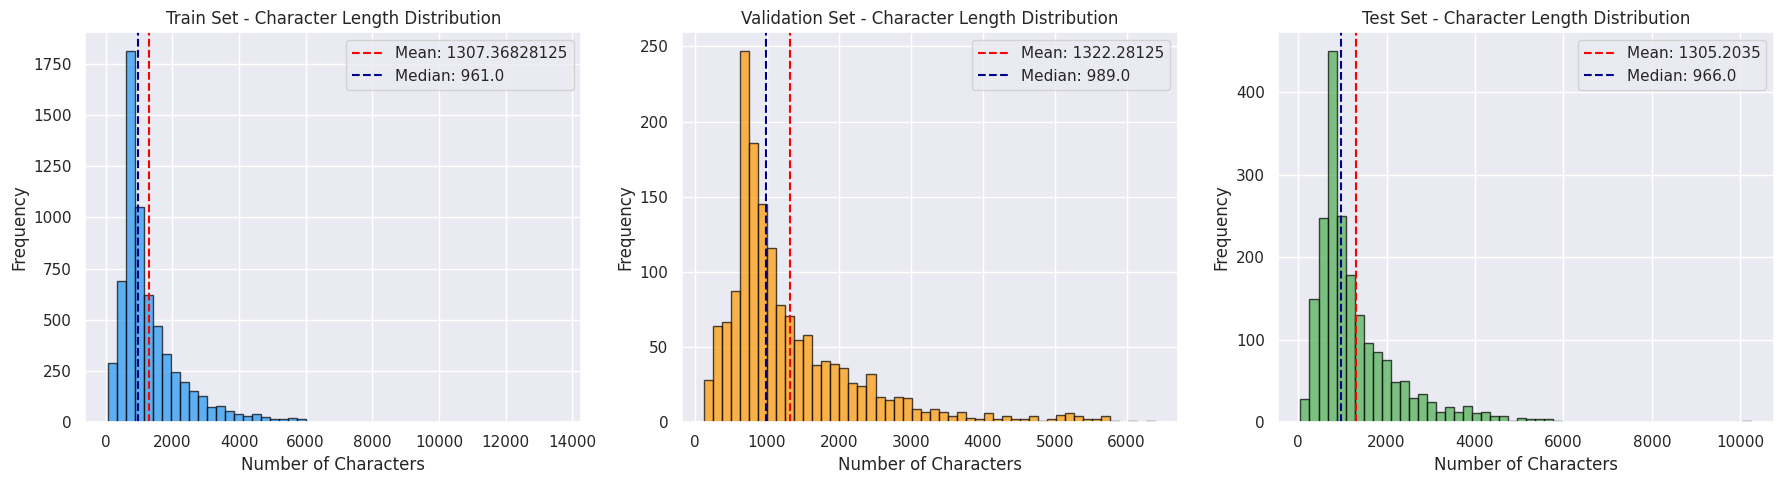

In [15]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

splits = {
    "Train": dataset_dict["train"]["text"],
    "Validation": dataset_dict["validation"]["text"],
    "Test": dataset_dict["test"]["text"]
}

colors = ["#2196F3", "#FF9800", "#4CAF50"]

for ax, (split_name, texts), color in zip(axes, splits.items(), colors):
    char_lengths = [len(t) for t in texts]

    ax.hist(char_lengths, bins=50, color=color, edgecolor="black", alpha=0.7)
    ax.axvline(np.mean(char_lengths), color="red", linestyle="--",
               label=f"Mean: {np.mean(char_lengths)}")
    ax.axvline(np.median(char_lengths), color="darkblue", linestyle="--",
               label=f"Median: {np.median(char_lengths)}")
    ax.set_title(f"{split_name} Set - Character Length Distribution")
    ax.set_xlabel("Number of Characters")
    ax.set_ylabel("Frequency")
    ax.legend()

    print(f"{split_name}: Mean={np.mean(char_lengths)}, "
          f"Median={np.median(char_lengths)}, "
          f"Min={np.min(char_lengths)}, Max={np.max(char_lengths)}, "
          f"Std={np.std(char_lengths)}")

plt.tight_layout()
plt.show()

Tenemos en todos los sets una mediana generalmente de casi 1000 carácteres. Se ve algún outlier de tamaño 10254.
Es cierto que en este punto deberíamos fijarnos solamente en los sets de entrenamiento y validación. Consideraría un tamaño máximo de 6000 carácteres.

A continuación haremos lo mismo contando palabras, separando por espacios en blanco.

Train: Mean=232.32203125, Median=173.0, Min=12, Max=2459, Std=172.68336779963502
Validation: Mean=234.566875, Median=176.0, Min=27, Max=1070, Std=170.30122365307412
Test: Mean=232.378, Median=172.0, Min=10, Max=1832, Std=170.91052956444784


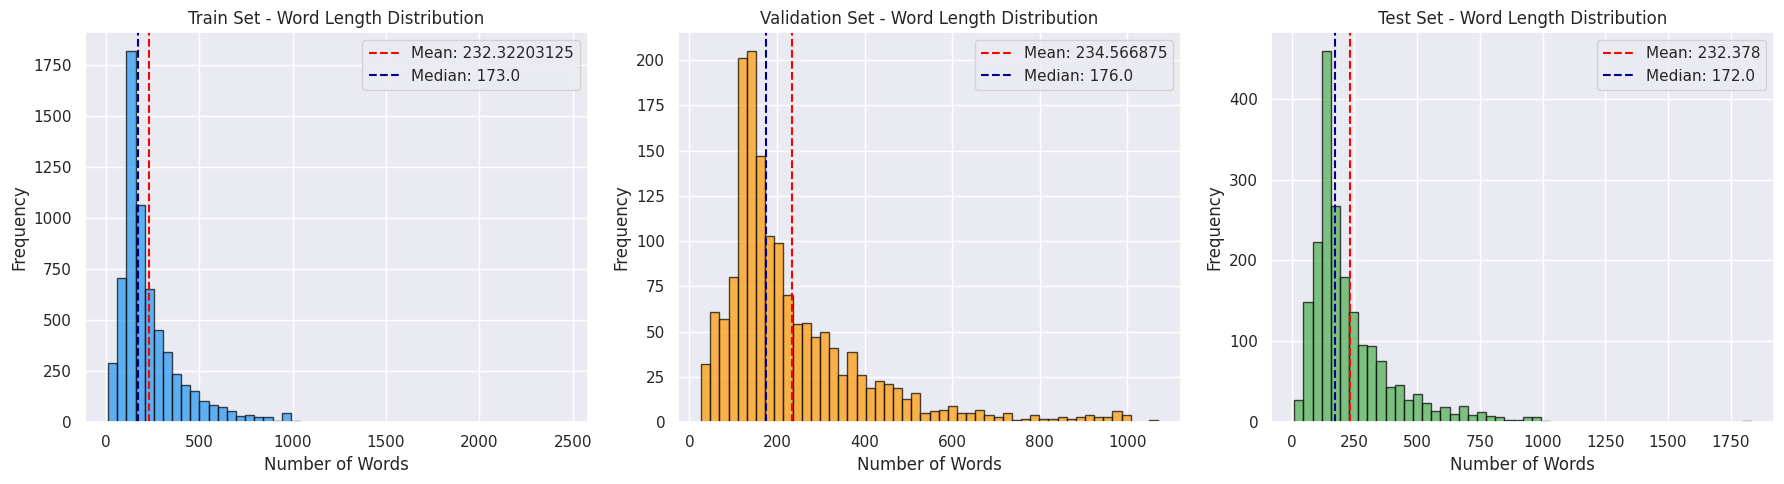

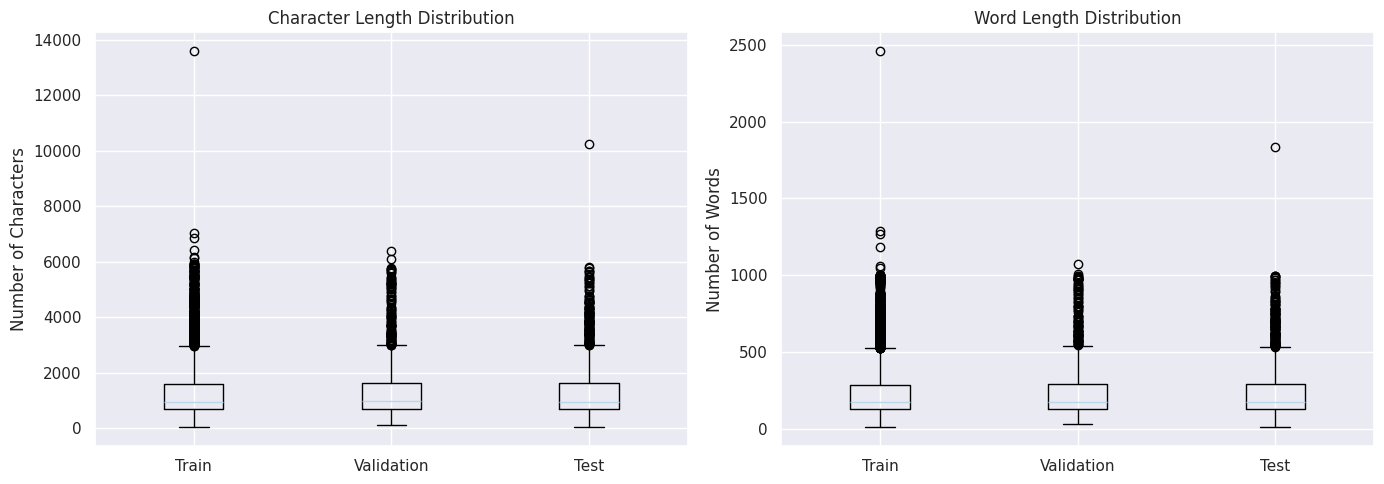

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ["#2196F3", "#FF9800", "#4CAF50"]

for ax, (split_name, texts), color in zip(axes, splits.items(), colors):
    word_lengths = [len(t.split()) for t in texts]

    ax.hist(word_lengths, bins=50, color=color, edgecolor="black", alpha=0.7)
    ax.axvline(np.mean(word_lengths), color="red", linestyle="--",
               label=f"Mean: {np.mean(word_lengths)}")
    ax.axvline(np.median(word_lengths), color="darkblue", linestyle="--",
               label=f"Median: {np.median(word_lengths)}")
    ax.set_title(f"{split_name} Set - Word Length Distribution")
    ax.set_xlabel("Number of Words")
    ax.set_ylabel("Frequency")
    ax.legend()

    print(f"{split_name}: Mean={np.mean(word_lengths)}, "
          f"Median={np.median(word_lengths)}, "
          f"Min={np.min(word_lengths)}, Max={np.max(word_lengths)}, "
          f"Std={np.std(word_lengths)}")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

char_data = [[len(t) for t in texts] for texts in splits.values()]
word_data = [[len(t.split()) for t in texts] for texts in splits.values()]

axes[0].boxplot(char_data, labels=splits.keys())
axes[0].set_title("Character Length Distribution")
axes[0].set_ylabel("Number of Characters")

axes[1].boxplot(word_data, labels=splits.keys())
axes[1].set_title("Word Length Distribution")
axes[1].set_ylabel("Number of Words")

plt.tight_layout()
plt.show()

En este caso tenemos una mediana sobre 175 palabras y un tamaño máximo cercano a 1000 palabras en las reviews procesadas.

# Modelos Contextuales

### Utilidades

A continuación vamos a definir una serie de utilidades que utilizaremos posteriormente para hacer el fine tuning de los modelos y evaluarlos. Comenzamos por imports.

In [17]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)

2026-03-29 13:51:36.065235: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Definimos esta función para evaluar en el dataset de test. Reportamos la accuracy y f1-score con los métodos de sklearn.

In [18]:
def evaluate_model(
    y_true,
    y_pred,
    target_labels,
    title="Model",
):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")

    # Classification Report
    print(f"CLASSIFICATION REPORT ({title})")
    print(classification_report(y_true, y_pred, target_names=target_labels))

    # Confusion Matrices
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_labels)
    disp.plot(ax=axes[0], cmap="Oranges", values_format="d")
    axes[0].set_title(f"{title} - Confusion Matrix (Counts)")

    cm_norm = confusion_matrix(y_true, y_pred, normalize="true")
    disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=target_labels)
    disp_norm.plot(ax=axes[1], cmap="Oranges", values_format=".2%")
    axes[1].set_title(f"{title} - Confusion Matrix (Normalized)")

    plt.tight_layout()
    plt.show()

    metrics = {"accuracy": acc, "f1": f1}

    print(f"Evaluation obtained the following metrics: {metrics}")

    return metrics

Defino este wrapper para evaluar directamente dado un trainer. Esto es util para asegurarse de que estamos evaluando con
los pesos habiendo hecho el fine tuning. Vamos a medir el tiempo de inferencia para comparar entre modelos.

In [19]:
import time

def evaluate_from_trainer(trainer, tokenized_test_dataset, y_true, target_labels, **kwargs):
    start_time = time.time()
    predictions = trainer.predict(tokenized_test_dataset)
    inference_time = time.time() - start_time

    print(f"Inference time: {inference_time}s")
    print(f"Samples/second: {len(y_true)/inference_time}")

    y_pred = np.argmax(predictions.predictions, axis=1)
    return evaluate_model(y_true, y_pred, target_labels, **kwargs)

Con este método mostraremos el número de parámetros que tiene un modelo.

In [20]:
def show_params(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"Total parameters:     {total_params}")
    print(f"Trainable parameters: {trainable_params}")

Con este método mostraremos métricas de entrenamiento que incluyen:
- Train loss
- Val loss
- Val accuracy
- Val f1-score

Se pasa una lista de logs porque quiero comparar diferentes entrenamientos con un for loop (para hacer un sweep de un hiper parámetro por ejemplo).

In [21]:
import matplotlib.pyplot as plt


def plot_training_histories(log_histories, labels, title="Fine-Tuning", save_path=None):
    if len(log_histories) != len(labels):
        raise ValueError(
            f"Number of log_histories ({len(log_histories)}) must match "
            f"number of labels ({len(labels)})"
        )

    colors = [
        "#2196F3", "#FF9800", "#4CAF50", "#E91E63",
        "#9C27B0", "#00BCD4", "#FF5722", "#795548",
        "#607D8B", "#CDDC39", "#3F51B5", "#F44336",
    ]

    _, axes = plt.subplots(1, 4, figsize=(24, 5))

    for i, (log_history, label) in enumerate(zip(log_histories, labels)):
        color = colors[i % len(colors)]

        train_losses = [
            (entry["step"], entry["loss"])
            for entry in log_history
            if "loss" in entry and "eval_loss" not in entry
        ]

        eval_entries = [entry for entry in log_history if "eval_loss" in entry]
        eval_epochs = list(range(1, len(eval_entries) + 1))

        # Training Loss
        if train_losses:
            steps, losses = zip(*train_losses)
            axes[0].plot(steps, losses, color=color, label=label, alpha=0.8)

        # Val Loss
        if eval_entries:
            axes[1].plot(
                eval_epochs, [e["eval_loss"] for e in eval_entries],
                color=color, marker="o", label=label
            )

            # Val F1
            if "eval_f1" in eval_entries[0]:
                axes[2].plot(
                    eval_epochs, [e["eval_f1"] for e in eval_entries],
                    color=color, marker="s", label=label
                )

            # Val Accuracy
            if "eval_accuracy" in eval_entries[0]:
                axes[3].plot(
                    eval_epochs, [e["eval_accuracy"] for e in eval_entries],
                    color=color, marker="^", label=label
                )

    axes[0].set_title("Training Loss")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].set_title("Validation Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    axes[2].set_title("Validation F1")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("F1")
    axes[2].legend()

    axes[3].set_title("Validation Accuracy")
    axes[3].set_xlabel("Epoch")
    axes[3].set_ylabel("Accuracy")
    axes[3].legend()

    plt.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()

Este método se usa para calcular las métricas en el dataset de **validación** durante entrenamiento.

In [22]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="weighted")
    return {"accuracy": acc, "f1": f1}


Defino un eval batch size para utilizar en la evaluación del dataset de test. Quiero que todas las evaluaciones usen
el mismo batch para poder comparar tiempos en "igualdad" de condiciones entre diferentes modelos.

In [23]:
EVAL_BATCH_SIZE = 32

### Model distilbert-base-uncased

distilbert-base-uncased

https://huggingface.co/distilbert/distilbert-base-uncased

Quiero empezar por ver cuál es la distribución de longitudes de secuencias de tokens con el tokenizador que utiliza distilbert-base-uncased.

Token indices sequence length is longer than the specified maximum sequence length for this model (544 > 512). Running this sequence through the model will result in indexing errors


Train: Mean=298.481875, Median=220.0, Max=3047
Validation: Mean=301.47, Median=227.0, Max=1415
Test: Mean=298.6355, Median=221.0, Max=2084


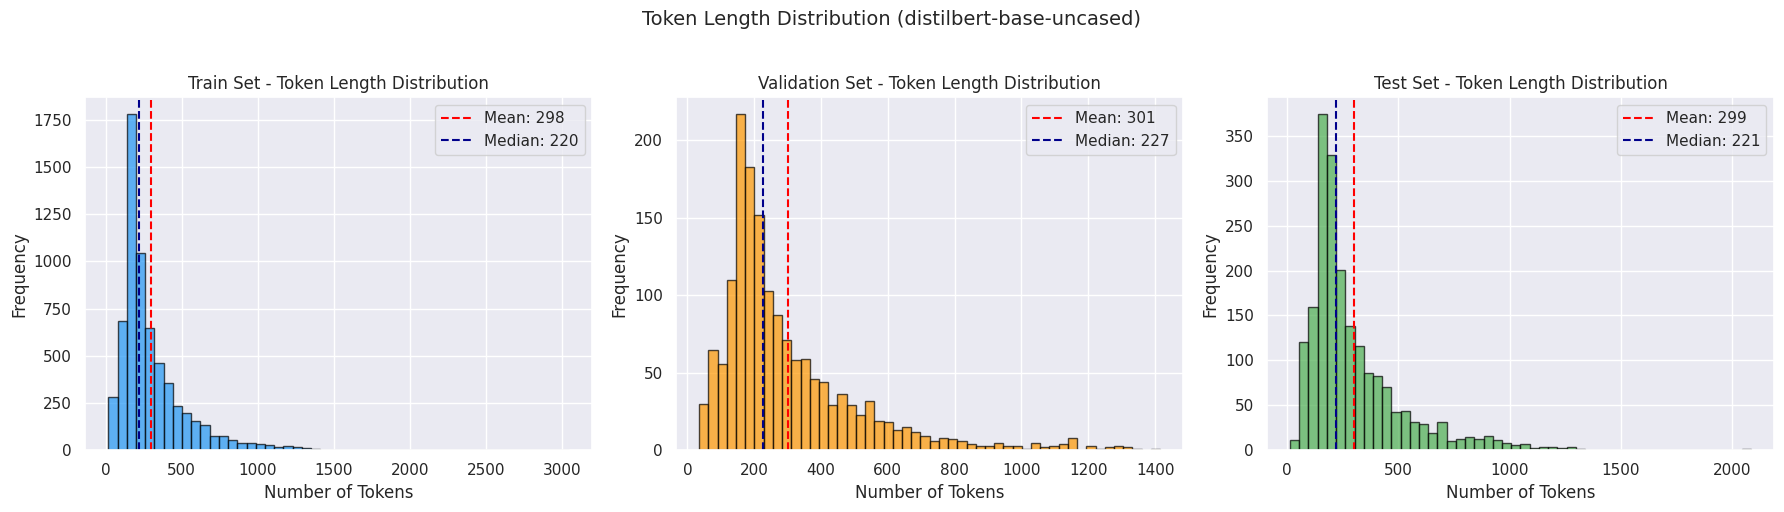

In [24]:
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import numpy as np

MODEL_CHECKPOINT = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

splits = {
    "Train": dataset_dict["train"]["text"],
    "Validation": dataset_dict["validation"]["text"],
    "Test": dataset_dict["test"]["text"],
}

colors = ["#2196F3", "#FF9800", "#4CAF50"]

for ax, (split_name, texts), color in zip(axes, splits.items(), colors):
    token_lengths = [len(tokenizer.encode(t)) for t in texts]

    ax.hist(token_lengths, bins=50, color=color, edgecolor="black", alpha=0.7)
    ax.axvline(np.mean(token_lengths), color="red", linestyle="--",
               label=f"Mean: {np.mean(token_lengths):.0f}")
    ax.axvline(np.median(token_lengths), color="darkblue", linestyle="--",
               label=f"Median: {np.median(token_lengths):.0f}")
    ax.set_title(f"{split_name} Set - Token Length Distribution")
    ax.set_xlabel("Number of Tokens")
    ax.set_ylabel("Frequency")
    ax.legend()

    over_512 = sum(1 for l in token_lengths if l > 512)
    print(f"{split_name}: "
          f"Mean={np.mean(token_lengths)}, "
          f"Median={np.median(token_lengths)}, "
          f"Max={np.max(token_lengths)}")

plt.suptitle(f"Token Length Distribution ({MODEL_CHECKPOINT})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Se obtiene una mediana sobre 220 tokens. Se lanza además un warning cuando se pasan secuencias de longitud superiores a 512. Vamos a utilizar una longitud máxima de 512 para entrenar este modelo. Además encuentro que en documentaciones, la longitud máxima de este modelo es 512:
https://catalog.ngc.nvidia.com/orgs/nvidia/teams/nemo/models/punctuation_en_distilbert?version=1.0.0rc1
Vamos a utilizar entonces 512.

In [25]:
MAX_LENGTH = 512

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=MAX_LENGTH)

tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)
print(tokenized_datasets)

Map: 100%|██████████| 2000/2000 [00:00<00:00, 6128.25 examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 6400
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 1600
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
})


In [26]:
target_labels = ["negative", "positive"]
num_labels = len(target_labels)
id2label = {i: label for i, label in enumerate(target_labels)}
label2id = {label: i for i, label in enumerate(target_labels)}

Quiero hacer un pequeño sweep del batch size para entender cuánta memoria se consume en la GPU y si hay alguna variación en el performance. El learning rate es pequeño 2-5 porque estamos fine tuneando un modelo pre entrenado y relativamente grande. Si hubiese una gran variación en los pesos, tenemos el riesgo de perder la extracción de características pre-aprendida. Los entrenamientos los estoy haciendo con una **GPU RTX 3090** y revisando la memoria consumida con **nvtop**.

In [27]:
batch_sizes = [16, 32, 64]
all_results = {}

for bs in batch_sizes:
    print(f"TRAINING WITH BATCH SIZE = {bs}")

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_CHECKPOINT,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    )

    show_params(model)

    training_args = TrainingArguments(
        output_dir=f"./distilbert-imdb-bs{bs}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=3,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        logging_steps=50,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=42,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        compute_metrics=compute_metrics,
    )

    train_result = trainer.train()

    training_time = train_result.metrics["train_runtime"]
    print(f"Training time: {training_time}s")

    all_results[bs] = {
        "trainer": trainer,
        "log_history": trainer.state.log_history,
    }

    print(f"Batch size {bs} complete!")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


TRAINING WITH BATCH SIZE = 16
Total parameters:     66955010
Trainable parameters: 66955010


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.289000,0.283313,0.885000,0.884383
2,0.181300,0.269721,0.918750,0.918751
3,0.112500,0.302117,0.923125,0.923125


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training time: 102.2186s
Batch size 16 complete!
TRAINING WITH BATCH SIZE = 32
Total parameters:     66955010
Trainable parameters: 66955010


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.277200,0.236801,0.905000,0.904960
2,0.192800,0.230402,0.915000,0.914991
3,0.111700,0.249637,0.916875,0.916876


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training time: 93.6487s
Batch size 32 complete!
TRAINING WITH BATCH SIZE = 64
Total parameters:     66955010
Trainable parameters: 66955010


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.302900,0.255078,0.905000,0.904834
2,0.202100,0.242043,0.908750,0.908697
3,0.157600,0.235943,0.915625,0.915621


Training time: 90.3361s
Batch size 64 complete!


Memoria consumida durante entrenamiento, y duración del entrenamiento:
- Batch size 16: 4Gb, 102.2186s
- Batch size 32: 6.2Gb, 93.6487s
- Batch size 64: 10.4Gb, 90.3361s

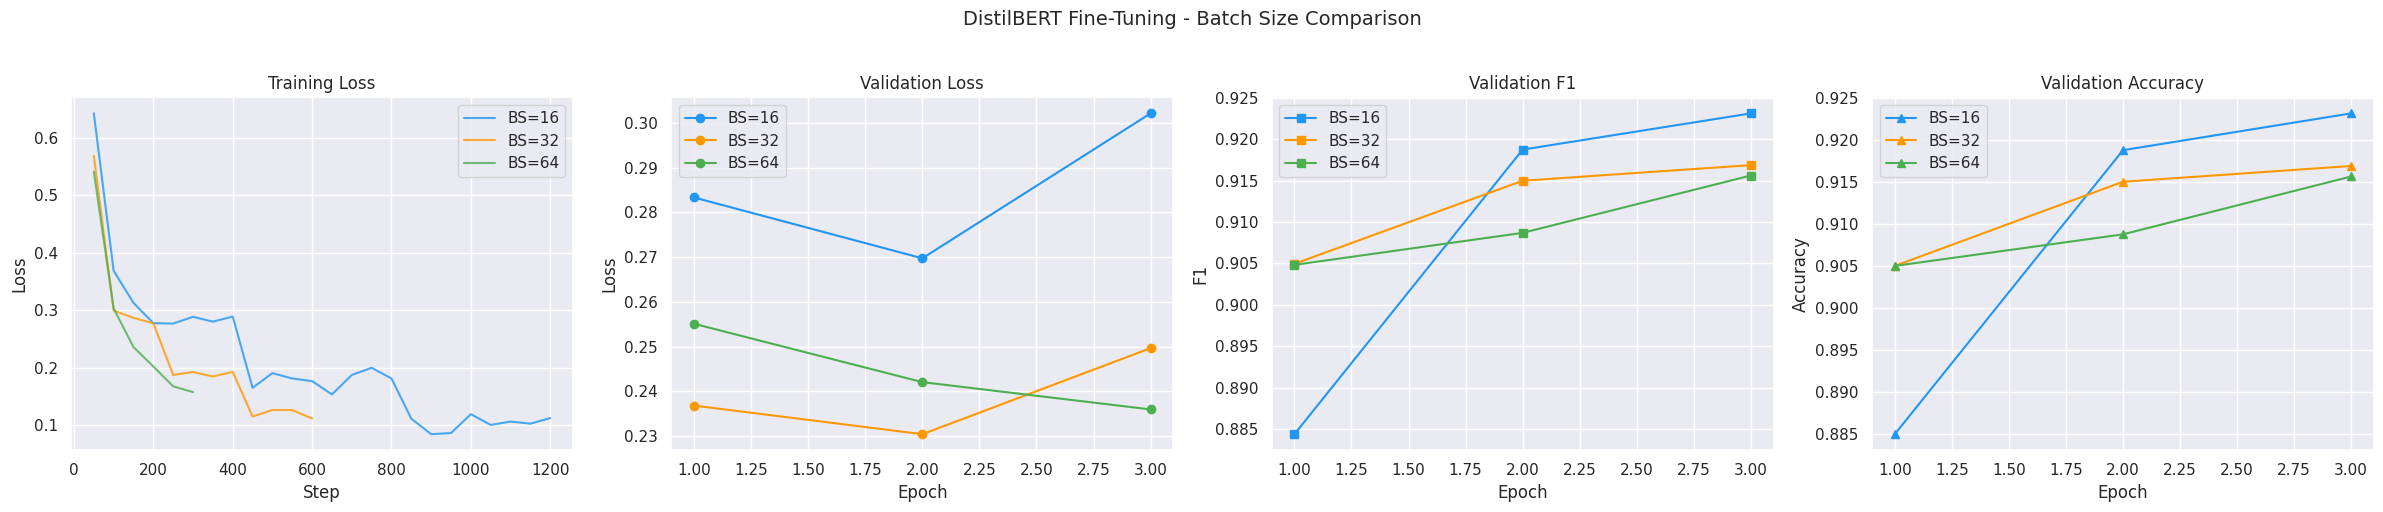

In [28]:
plot_training_histories(
    log_histories=[all_results[bs]["log_history"] for bs in batch_sizes],
    labels=[f"BS={bs}" for bs in batch_sizes],
    title="DistilBERT Fine-Tuning - Batch Size Comparison",
    save_path="distilbert_batch_size_comparison.png",
)

Después de ver estos resultados, a pesar de que batch size 16 tenga una peor validation loss, es el que mejor accuracy y F1 obtiene en validación. Por este motivo, vamos a evaluar el modelo entrenado con batch size 16 en el dataset de test.

Inference time: 2.8237576484680176s
Samples/second: 708.2760806633198
CLASSIFICATION REPORT (Model)
              precision    recall  f1-score   support

    negative       0.91      0.91      0.91      1025
    positive       0.91      0.90      0.91       975

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000



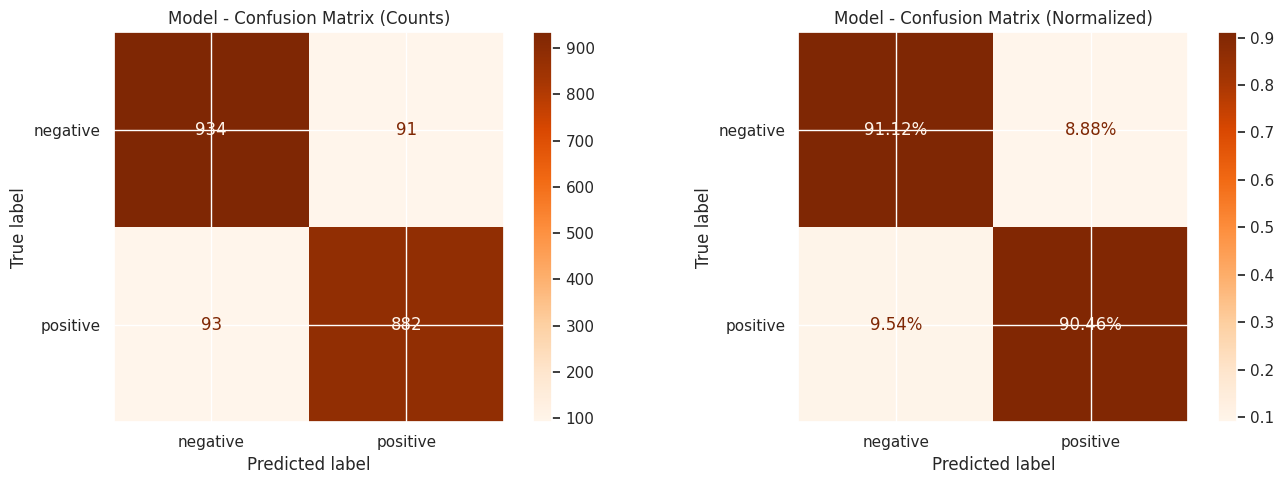

Evaluation obtained the following metrics: {'accuracy': 0.908, 'f1': 0.9079976063819143}


{'accuracy': 0.908, 'f1': 0.9079976063819143}

In [29]:
y_true = np.array(dataset_dict["test"]["label"])

evaluate_from_trainer(
    trainer=all_results[16]["trainer"],
    tokenized_test_dataset=tokenized_datasets["test"],
    y_true=y_true,
    target_labels=target_labels,
)

Obtenemos ya un resultado mejor que en las prácticas anteriores sin necesidad de haber tuneado muchos parámetros o habiendo hecho muchos experimentos.
- **Accuracy 90.8%**

### Model allenai/longformer-base-4096 (más context)

allenai/longformer-base-4096

https://huggingface.co/allenai/longformer-base-4096

En el entrenamiento anterior, hemos recortado las secuencias a un tamaño de 512 y un porcentaje considerable de reviews tienen una longitud mayor. Por este motivo, ahora quiero entrenar un modelo que permita una longitud de secuencias mayor. Vamos a utilizar el modelo longformer con max len 1024.

Tal como dice la documentación de hugging face, longformer es un modelo basado en transformers que procesa documentos largos. Soporta secuencias de hasta 4096 tokens. Es un modelo con una arquitectura similar a BERT. 

In [30]:
LONGFORMER_CHECKPOINT = "allenai/longformer-base-4096"
longformer_tokenizer = AutoTokenizer.from_pretrained(LONGFORMER_CHECKPOINT)

print(f"Model: {LONGFORMER_CHECKPOINT}")
print(f"Model max length: {longformer_tokenizer.model_max_length}")
print(f"Vocab size: {longformer_tokenizer.vocab_size}")

Model: allenai/longformer-base-4096
Model max length: 1000000000000000019884624838656
Vocab size: 50265


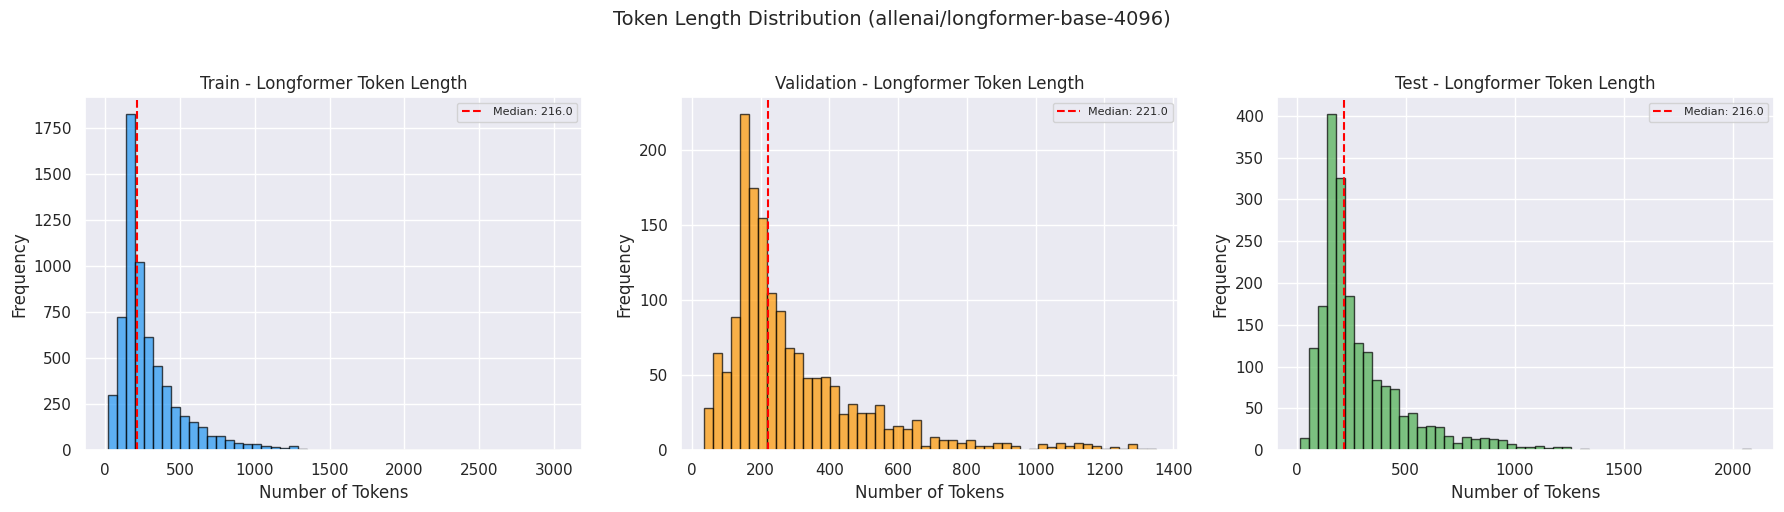

In [31]:
token_lengths_per_split = {}

for split_name, texts in splits.items():
    lengths = [len(longformer_tokenizer.encode(text, truncation=False)) for text in texts]
    token_lengths_per_split[split_name] = lengths

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ["#2196F3", "#FF9800", "#4CAF50"]

for ax, (split_name, lengths), color in zip(axes, token_lengths_per_split.items(), colors):
    ax.hist(lengths, bins=50, color=color, edgecolor="black", alpha=0.7)
    ax.axvline(np.median(lengths), color="red", linestyle="--",
               label=f"Median: {np.median(lengths)}")
    ax.set_title(f"{split_name} - Longformer Token Length")
    ax.set_xlabel("Number of Tokens")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

plt.suptitle(f"Token Length Distribution ({LONGFORMER_CHECKPOINT})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


La media sigue siendo de alrededor de 220 tokens. Ahora vamos a considerar un tamaño máximo de 1024 tokens. Esta longitud abarca la mayor parte de reviews.

In [32]:
LONGFORMER_MAX_LENGTH = 1024

def longformer_tokenize_function(examples):
    return longformer_tokenizer(
        examples["text"],
        truncation=True,
        max_length=LONGFORMER_MAX_LENGTH
    )

longformer_tokenized_datasets = dataset_dict.map(longformer_tokenize_function, batched=True)

Map: 100%|██████████| 2000/2000 [00:00<00:00, 7847.06 examples/s]


Longformer es algo más grande y las secuencias también son más largas. Voy a usar un batch size de 8 esta vez.

In [33]:
LONGFORMER_CHECKPOINT = "allenai/longformer-base-4096"
LONGFORMER_MAX_LENGTH = 1024
BATCH_SIZE = 8
EPOCHS = 3
LEARNING_RATE = 2e-5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

num_labels = len(target_labels)

longformer_model = AutoModelForSequenceClassification.from_pretrained(
    LONGFORMER_CHECKPOINT,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

show_params(longformer_model)

Using device: cuda


Some weights of LongformerForSequenceClassification were not initialized from the model checkpoint at allenai/longformer-base-4096 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters:     148660994
Trainable parameters: 148660994


In [34]:
from transformers import DataCollatorWithPadding

longformer_data_collator = DataCollatorWithPadding(tokenizer=longformer_tokenizer)

longformer_training_args = TrainingArguments(
    output_dir="./results_longformer",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir="./logs_longformer",
    logging_steps=100,
    report_to="none",
    seed=42,
    fp16=torch.cuda.is_available(),
    gradient_accumulation_steps=2,
)

longformer_trainer = Trainer(
    model=longformer_model,
    args=longformer_training_args,
    train_dataset=longformer_tokenized_datasets["train"],
    eval_dataset=longformer_tokenized_datasets["validation"],
    tokenizer=longformer_tokenizer,
    data_collator=longformer_data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

longformer_train_result = longformer_trainer.train()

print(f"Training completed!")
print(f"Training loss: {longformer_train_result.training_loss}")
print(f"Training time: {longformer_train_result.metrics['train_runtime']}s")

Initializing global attention on CLS token...
Input ids are automatically padded to be a multiple of `config.attention_window`: 512


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.239000,0.239769,0.936250,0.936223
2,0.161300,0.249515,0.940625,0.940616
3,0.083300,0.288175,0.941250,0.941231


Training completed!
Training loss: 0.17587186694145202
Training time: 1007.5102s


Memoria consumida por este entrenamiento:
**18Gb**

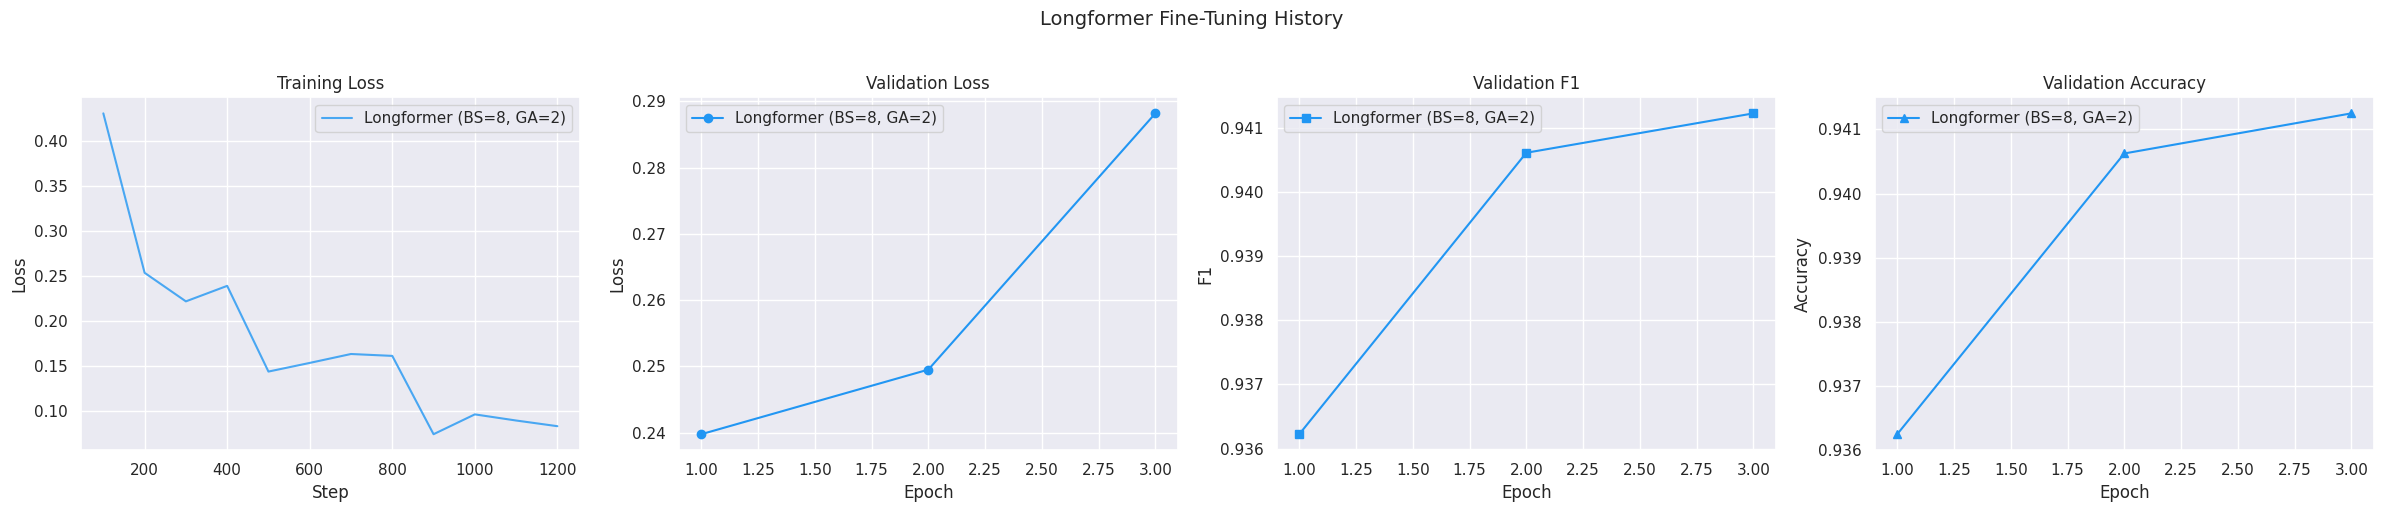

In [35]:
plot_training_histories(
    log_histories=[longformer_trainer.state.log_history],
    labels=["Longformer (BS=8, GA=2)"],
    title="Longformer Fine-Tuning History",
    save_path="longformer_training_history.png"
)

Inference time: 32.08421039581299s
Samples/second: 62.33595825880139
CLASSIFICATION REPORT (Model)
              precision    recall  f1-score   support

    negative       0.95      0.93      0.94      1025
    positive       0.92      0.95      0.94       975

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



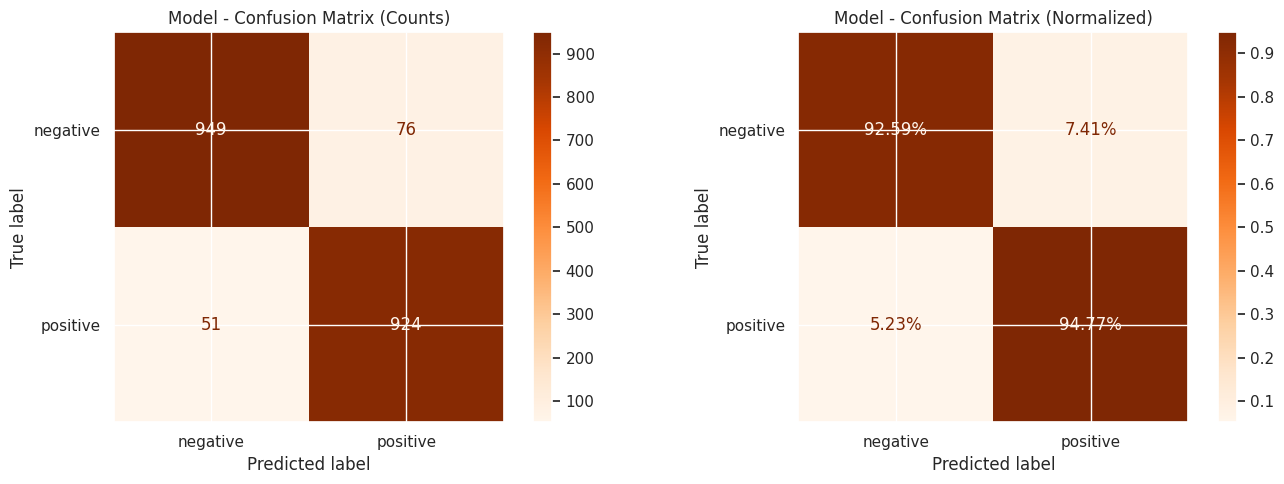

Evaluation obtained the following metrics: {'accuracy': 0.9365, 'f1': 0.9365099234255353}


In [36]:
y_true = np.array(dataset_dict["test"]["label"])

finetuned_metrics = evaluate_from_trainer(
    trainer=longformer_trainer,
    tokenized_test_dataset=longformer_tokenized_datasets["test"],
    y_true=y_true,
    target_labels=target_labels,
)

Con este modelo de más capacidad, se ha obtenido una mejor accuracy que la reportada en el modelo anterior.

## Evaluación checkpoint Sentiment Analysis

### Modelo distilbert/distilbert-base-uncased-finetuned-sst-2-english

Según la documentación de este modelo:
https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english

Este parte de distilbert/distilbert-base-uncased: https://huggingface.co/distilbert/distilbert-base-uncased.
Y ha sido fine tuneado en el dataset SST-2 https://huggingface.co/datasets/stanfordnlp/sst2
El cual está formado por todas estas muestras:
- train: 67349
- validation 872
- test 1821

Y consiste en Stanford Sentiment Treebank para un problema de clasificación binaria de sentimientos.

In [37]:
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch

PRETRAINED_CHECKPOINT = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"

pretrained_tokenizer = AutoTokenizer.from_pretrained(PRETRAINED_CHECKPOINT)
pretrained_model = AutoModelForSequenceClassification.from_pretrained(PRETRAINED_CHECKPOINT)

show_params(pretrained_model)

print(f"Model label mapping: {pretrained_model.config.id2label}")

# A continuación, vemos el label mapping del checkpoint seleccionado para hacer zero-shot evaluation
pretrained_label_map = {
    "NEGATIVE": label2id.get("negative", label2id.get("neg", 0)),
    "POSITIVE": label2id.get("positive", label2id.get("pos", 1)),
}
print(f"Mapping pretrained labels to yours: {pretrained_label_map}")

Total parameters:     66955010
Trainable parameters: 66955010
Model label mapping: {0: 'NEGATIVE', 1: 'POSITIVE'}
Mapping pretrained labels to yours: {'NEGATIVE': 0, 'POSITIVE': 1}


In [38]:
MAX_LENGTH = 512
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

tokenizer = pretrained_tokenizer

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)

sample = tokenized_datasets["train"][0]
print(f"Keys: {sample.keys()}")
print(f"Input IDs length: {len(sample['input_ids'])}")
print(f"Decoded: {tokenizer.decode(sample['input_ids'][:50])}...")

Using device: cuda


Map: 100%|██████████| 2000/2000 [00:00<00:00, 5180.30 examples/s]

Keys: dict_keys(['text', 'label', 'input_ids', 'attention_mask'])
Input IDs length: 512
Decoded: [CLS] my husband and i went to see this movie, being the horror movie buffs that we are. two hours later i found myself wanting both my money and time back. i was so disappointed. the teasers for this film basically contained the best...


Hacemos inferencia en el dataset de test.

In [39]:
from torch.utils.data import DataLoader
from tqdm import tqdm

pretrained_model.to(DEVICE)
pretrained_model.eval()

all_preds = []
all_probs = []
test_texts = dataset_dict["test"]["text"]

start_time = time.time()
for i in tqdm(range(0, len(test_texts), EVAL_BATCH_SIZE), desc="Evaluating pretrained model"):
    batch_texts = test_texts[i:i + EVAL_BATCH_SIZE]
    inputs = pretrained_tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():
        outputs = pretrained_model(**inputs)

    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    preds = torch.argmax(probs, dim=-1)

    mapped_preds = []
    for p in preds.cpu().numpy():
        pretrained_label_name = pretrained_model.config.id2label[p]
        mapped_preds.append(pretrained_label_map[pretrained_label_name])

    all_preds.extend(mapped_preds)
    all_probs.extend(probs.cpu().numpy())

inference_time = time.time() - start_time

print(f"Inference time: {inference_time}s")
print(f"Samples/second: {len(test_texts)/inference_time}")
print(f"Total samples: {len(test_texts)}")

y_pred_pretrained = np.array(all_preds)
all_probs = np.array(all_probs)

print("Inference complete!")

Evaluating pretrained model:   0%|          | 0/63 [00:00<?, ?it/s]

Evaluating pretrained model: 100%|██████████| 63/63 [00:07<00:00,  8.50it/s]

Inference time: 7.409436225891113s
Samples/second: 269.9260698150439
Total samples: 2000
Inference complete!


CLASSIFICATION REPORT (Pre-Trained Model - Zero Shot)
              precision    recall  f1-score   support

    negative       0.87      0.92      0.89      1025
    positive       0.91      0.85      0.88       975

    accuracy                           0.88      2000
   macro avg       0.89      0.88      0.88      2000
weighted avg       0.89      0.88      0.88      2000



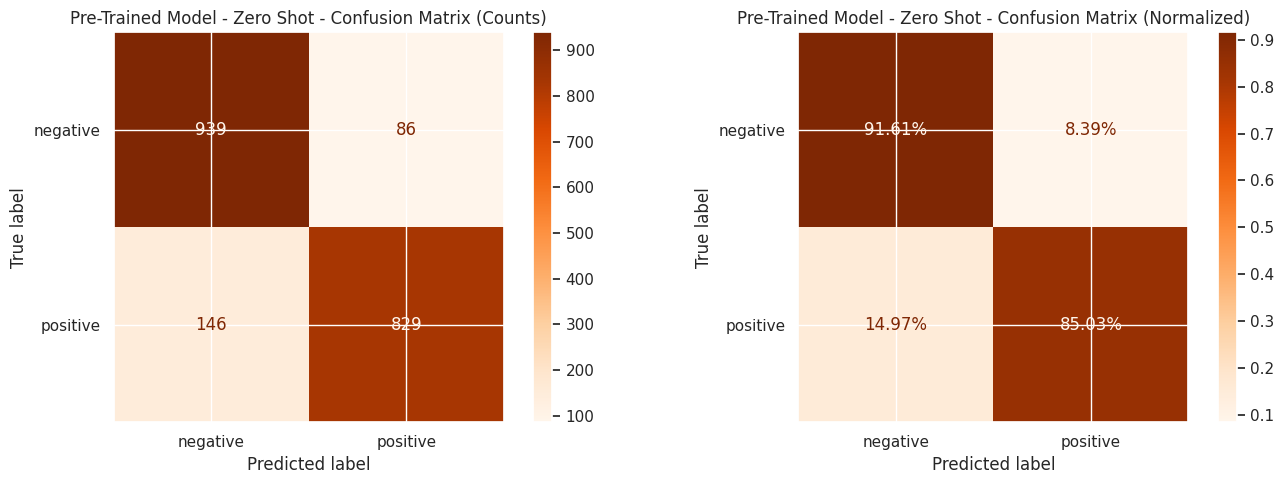

Evaluation obtained the following metrics: {'accuracy': 0.884, 'f1': 0.8838080192582564}
MODEL COMPARISON SUMMARY
                                                                 Model  Accuracy  F1 Score
                                    Fine-Tuned distilbert-base-uncased    0.9365  0.936510
Pre-Trained distilbert/distilbert-base-uncased-finetuned-sst-2-english    0.8840  0.883808


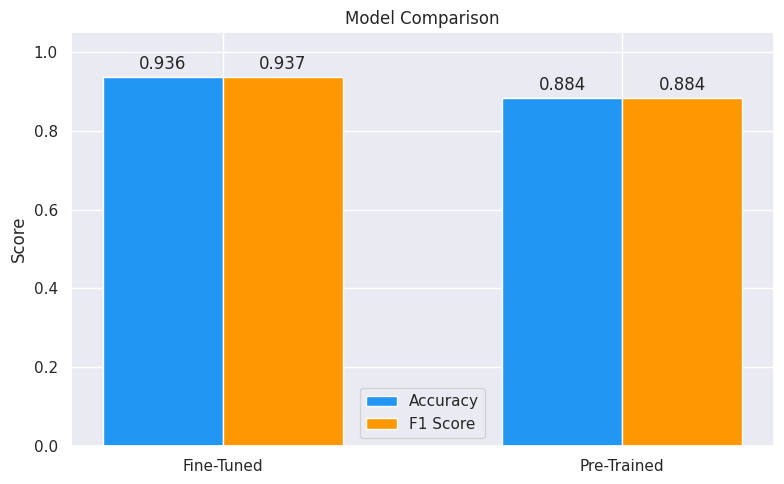

In [40]:
pretrained_metrics = evaluate_model(
    y_true=dataset_dict["test"]["label"],
    y_pred=y_pred_pretrained,
    target_labels=target_labels,
    title="Pre-Trained Model - Zero Shot",
)

print("MODEL COMPARISON SUMMARY")
comparison_data = {
    "Model": ["Fine-Tuned " + MODEL_CHECKPOINT, "Pre-Trained " + PRETRAINED_CHECKPOINT],
    "Accuracy": [finetuned_metrics["accuracy"], pretrained_metrics["accuracy"]],
    "F1 Score": [finetuned_metrics["f1"], pretrained_metrics["f1"]],
}
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
width = 0.3
bars1 = ax.bar(x - width/2, comparison_df["Accuracy"], width, label="Accuracy", color="#2196F3")
bars2 = ax.bar(x + width/2, comparison_df["F1 Score"], width, label="F1 Score", color="#FF9800")
ax.set_ylabel("Score")
ax.set_title("Model Comparison")
ax.set_xticks(x)
ax.set_xticklabels(["Fine-Tuned", "Pre-Trained"], rotation=0)
ax.legend()
ax.set_ylim(0, 1.05)
ax.bar_label(bars1, fmt="%.3f", padding=3)
ax.bar_label(bars2, fmt="%.3f", padding=3)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

La accuracy obtenida de 88.4% es algo peor que la del mejor modelo fine tuneado con el dataset objetivo (93.6%).

### Modelo siebert/sentiment-roberta-large-english

Este modelo según la documentación:
https://huggingface.co/siebert/sentiment-roberta-large-english

Es un modelo fine tuneado que partía de:
FacebookAI/roberta-large
https://huggingface.co/FacebookAI/roberta-large

Se dice que fue fine tuneado y evaluado en 15 datasets asociados a tareas de clasificación de sentimientos binaria en inglés. La documentación menciona que mejora a aquellos modelos que han sido fine tuneados solamente en SST-2.

In [41]:
PRETRAINED_CHECKPOINT_2 = "siebert/sentiment-roberta-large-english"

pretrained_tokenizer_2 = AutoTokenizer.from_pretrained(PRETRAINED_CHECKPOINT_2)
pretrained_model_2 = AutoModelForSequenceClassification.from_pretrained(PRETRAINED_CHECKPOINT_2)

show_params(pretrained_model_2)

print(f"Model label mapping: {pretrained_model_2.config.id2label}")

pretrained_label_map_2 = {
    "NEGATIVE": label2id.get("negative", label2id.get("neg", 0)),
    "POSITIVE": label2id.get("positive", label2id.get("pos", 1)),
}
print(f"Mapping pretrained labels to yours: {pretrained_label_map_2}")

Total parameters:     355361794
Trainable parameters: 355361794
Model label mapping: {0: 'NEGATIVE', 1: 'POSITIVE'}
Mapping pretrained labels to yours: {'NEGATIVE': 0, 'POSITIVE': 1}


In [42]:
pretrained_model_2.to(DEVICE)
pretrained_model_2.eval()

all_preds_2 = []
all_probs_2 = []
test_texts = dataset_dict["test"]["text"]

start_time = time.time()

for i in tqdm(range(0, len(test_texts), EVAL_BATCH_SIZE), desc="Evaluating siebert model"):
    batch_texts = test_texts[i:i + EVAL_BATCH_SIZE]
    inputs = pretrained_tokenizer_2(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():
        outputs = pretrained_model_2(**inputs)

    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    preds = torch.argmax(probs, dim=-1)

    mapped_preds = []
    for p in preds.cpu().numpy():
        pretrained_label_name = pretrained_model_2.config.id2label[p]
        mapped_preds.append(pretrained_label_map_2[pretrained_label_name])

    all_preds_2.extend(mapped_preds)
    all_probs_2.extend(probs.cpu().numpy())

inference_time = time.time() - start_time

print(f"Inference time: {inference_time:.1f}s")
print(f"Samples/second: {len(test_texts)/inference_time}")
print(f"Total samples: {len(test_texts)}")

y_pred_pretrained_2 = np.array(all_preds_2)
all_probs_2 = np.array(all_probs_2)
print("Inference complete!")

Evaluating siebert model: 100%|██████████| 63/63 [00:43<00:00,  1.45it/s]

Inference time: 43.5s
Samples/second: 46.02587956046276
Total samples: 2000
Inference complete!


CLASSIFICATION REPORT (Pre-Trained Siebert - Zero Shot)
              precision    recall  f1-score   support

    negative       0.95      0.95      0.95      1025
    positive       0.95      0.95      0.95       975

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



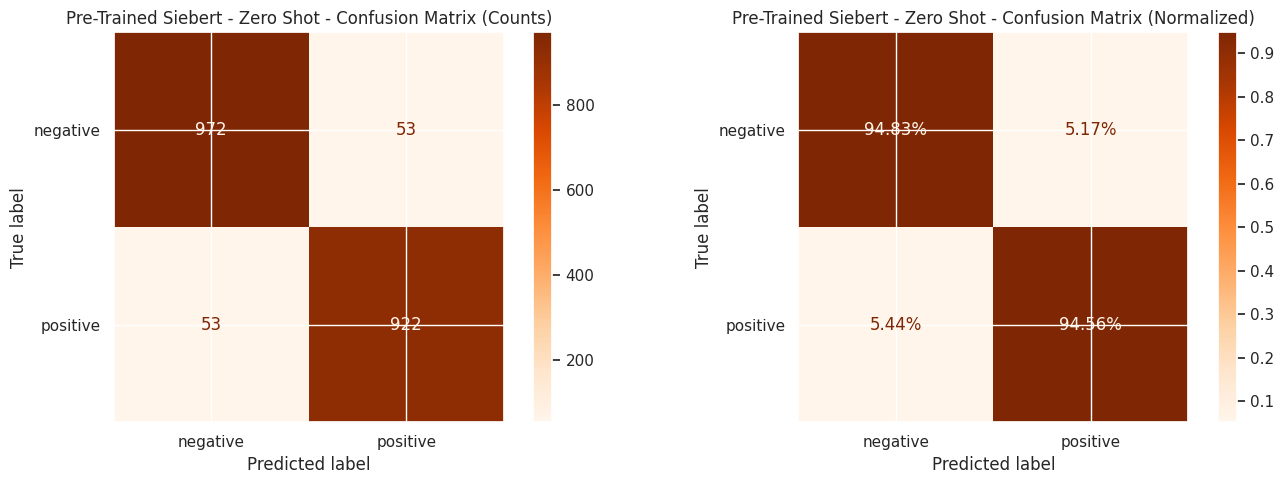

Evaluation obtained the following metrics: {'accuracy': 0.947, 'f1': 0.947}
MODEL COMPARISON SUMMARY
                                                                 Model  Accuracy  F1 Score
                                    Fine-Tuned distilbert-base-uncased    0.9365  0.936510
Pre-Trained distilbert/distilbert-base-uncased-finetuned-sst-2-english    0.8840  0.883808
                   Pre-Trained siebert/sentiment-roberta-large-english    0.9470  0.947000


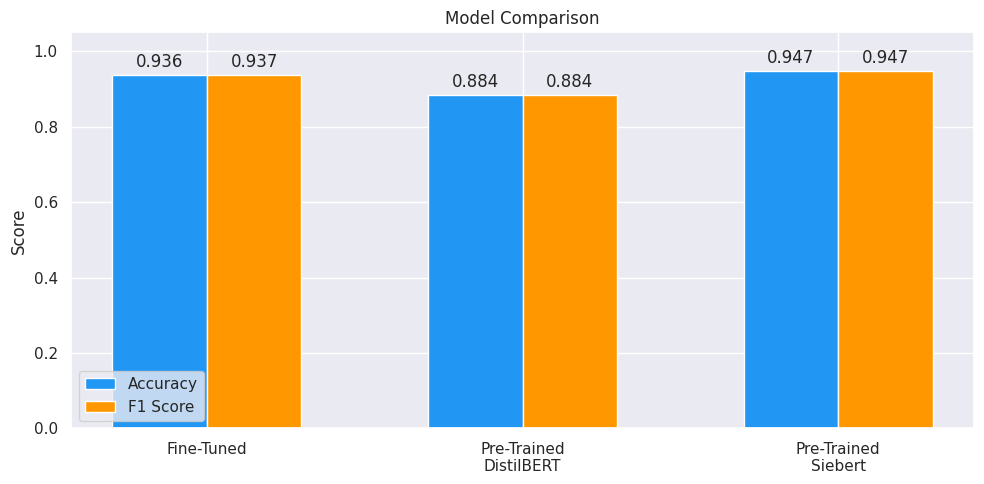

In [44]:
pretrained_metrics_2 = evaluate_model(
    y_true=dataset_dict["test"]["label"],
    y_pred=y_pred_pretrained_2,
    target_labels=target_labels,
    title="Pre-Trained Siebert - Zero Shot",
)

print("MODEL COMPARISON SUMMARY")
comparison_data = {
    "Model": [
        "Fine-Tuned " + MODEL_CHECKPOINT,
        "Pre-Trained " + PRETRAINED_CHECKPOINT,
        "Pre-Trained " + PRETRAINED_CHECKPOINT_2,
    ],
    "Accuracy": [
        finetuned_metrics["accuracy"],
        pretrained_metrics["accuracy"],
        pretrained_metrics_2["accuracy"],
    ],
    "F1 Score": [
        finetuned_metrics["f1"],
        pretrained_metrics["f1"],
        pretrained_metrics_2["f1"],
    ],
}
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(3)
width = 0.3
bars1 = ax.bar(x - width/2, comparison_df["Accuracy"], width, label="Accuracy", color="#2196F3")
bars2 = ax.bar(x + width/2, comparison_df["F1 Score"], width, label="F1 Score", color="#FF9800")
ax.set_ylabel("Score")
ax.set_title("Model Comparison")
ax.set_xticks(x)
ax.set_xticklabels(["Fine-Tuned", "Pre-Trained\nDistilBERT", "Pre-Trained\nSiebert"], rotation=0)
ax.legend()
ax.set_ylim(0, 1.05)
ax.bar_label(bars1, fmt="%.3f", padding=3)
ax.bar_label(bars2, fmt="%.3f", padding=3)
plt.tight_layout()
plt.show()

Este modelo de más capacidad obtiene mejor accuracy que incluso el modelo que ha sido fine tuneado en nuestro dataset. La documentación de siebert/sentiment-roberta-large-english ya sugiere que este es bastante robusto porque ha sido entrenado en diferentes datasets y mejora a aquellos que han sido entrenados en solamente uno como en el dataset SST-2.

# Conclusiones

En la tabla se han resaltado las mejores métricas, considerando que:
- Mayor accuracy es mejor
- Menor tiempo de entrenamiento es mejor
- Menor memoria consumida en entrenamiento es mejor
- Menor tiempo de evaluación es mejor
- Menor número de parámetros es mejor

| Model | Accuracy (%) | Training Time (s) | Training Memory (GB) | Evaluation Time (s) | Number of Parameters |
|-------|----------|---------------|-----------------|-----------------|----------------------|
| distilbert-base-uncased | 90.8 | **102.21** | **4** | **2.823** | **66,955,010** |
| allenai/longformer-base-4096 | 93.65 | 1007.51| 18 | 32.08 | 148,660,994 |
| distilbert/distilbert-base-uncased-finetuned-sst-2-english (zero-shot) | 88.4 | - | - | 6.882 | **66,955,010** |
| siebert/sentiment-roberta-large-english (zero-shot) | **94.7** | - | - | 40.7 | 355,361,794 |


Una **primera comparación** que se puede hacer es que se han comparado dos modelos de la misma naturaleza:
- distilbert-base-uncased
- distilbert/distilbert-base-uncased-finetuned-sst-2-english

Con el primero se ha hecho finetuning en nuestro dataset. El segundo según la documentación, parte del mismo distilbert-base-uncased y se le hizo fine tuning en el dataset SST-2 https://huggingface.co/datasets/stanfordnlp/sst2, donde alcanza en este dataset (en test) una accuracy de 91.3%. La evaluación de este checkpoint obtiene una accuracy algo más baja, concretamente de 88.4%. Esto se puede explicar si hay cambios significativos entre nuestro dataset de reviews de películas y el dataset SST-2. Quizá el cambio de estilo y el vocabulario asociado a películas explique esta menor accuracy.

Por otra parte, haciendo el fine tuning, sí se obtiene una accuracy similar a 91.3%, en concreto 90.8%.

En **segundo lugar**, de estos experimentos creo que se puede sacar la conclusión de que **a más número de parámetros, mejor es la accuracy en test**. Esto ha sucedido tanto en los dos finetunings donde el modelo con más capacidad (longformer) ha obtenido mejor resultado en test.

También, en los dos experimentos zero-shot, el modelo con más capacidad (roberta-large) ha obtenido mejor accuracy en test.

**Sin embargo**, se puede ver que en los modelos de **mayor capacidad**, la **inferencia dura más tiempo**. El **tiempo de entrenamiento también es considerablemente más largo**.

La elección de un modelo en producción dependerá entonces de la capacidad de cómputo que se tenga, del tiempo de inferencia que quiera conseguir y de los errores que sean "permitibles". Por ejemplo, hay aplicaciones donde el procesado se realiza en tiempo real con el usuario y probablemente estas necesiten una inferencia muy rápida para que la experiencia sea más fluida. Otras aplicaciones podrían hacer el procesado offline y quizá importa menos la duración de la inferencia.

Como resumen, en esta práctica hemos realizado un fine tuning de 2 modelos pre entrenados y hemos visto las diferencias entre sus resultados. Así mismo, se ha hecho un pequeño estudio sobre el uso de diferentes tamaños de batch para entender la memoria consumida en la GPU y diferencias en el tiempo de entrenamiento y en las métricas del modelo generado.

Posteriormente, se han realizado dos evaluaciones zero-shot a nuestro dataset de dos modelos ya adecuados para nuestra tarea de clasificación de sentimientos binaria.

Finalmente, se han mostrado en una tabla todos los resultados obtenidos y se han comentado atendiendo a los tiempos de entrenamiento, el número de parámetros de cada modelo, sus accuracies en test, etc.